In [33]:
# thư viện tính toán số học 
import numpy as np

# thư viện xử lý dữ liệu dạng bảng
import pandas as pd
 # thư viện trực quan hóa dữ liệuu
import matplotlib.pyplot as plt

import seaborn as sns

In [34]:
#Import mô hình các công cụ từ sklearn 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [37]:
#đọc flie csv
data = pd.read_csv(
    '/home/vophilong/Documents/BTap_DeepLearning/BaiTapDeepLearning/VoPhiLong_2280601798/dataset/archive/car_purchasing.csv',
    encoding='latin1'
)

print(data.head())
#hiển thị 5 dòng đầu tiên của dữ liệu
print(data.head())

     customer name                                    customer e-mail  \
0    Martina Avila  cubilia.Curae.Phasellus@quisaccumsanconvallis.edu   
1    Harlan Barnes                                eu.dolor@diam.co.uk   
2  Naomi Rodriquez  vulputate.mauris.sagittis@ametconsectetueradip...   
3  Jade Cunningham                            malesuada@dignissim.com   
4     Cedric Leach     felis.ullamcorper.viverra@egetmollislectus.net   

        country  gender        age  annual Salary  credit card debt  \
0      Bulgaria       0  41.851720    62812.09301      11609.380910   
1        Belize       0  40.870623    66646.89292       9572.957136   
2       Algeria       1  43.152897    53798.55112      11160.355060   
3  Cook Islands       1  58.271369    79370.03798      14426.164850   
4        Brazil       1  57.313749    59729.15130       5358.712177   

     net worth  car purchase amount  
0  238961.2505          35321.45877  
1  530973.9078          45115.52566  
2  638467.1773      

In [38]:
#kiểm tra thông tin dữ liệu
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer name        500 non-null    object 
 1   customer e-mail      500 non-null    object 
 2   country              500 non-null    object 
 3   gender               500 non-null    int64  
 4   age                  500 non-null    float64
 5   annual Salary        500 non-null    float64
 6   credit card debt     500 non-null    float64
 7   net worth            500 non-null    float64
 8   car purchase amount  500 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 35.3+ KB
None
           gender         age  annual Salary  credit card debt  \
count  500.000000  500.000000     500.000000        500.000000   
mean     0.506000   46.241674   62127.239608       9607.645049   
std      0.500465    7.978862   11703.378228       3489.187973   
min      0.000

In [39]:
#chọn các cột x và y

X = data[['age', 'annual Salary', 'credit card debt', 'net worth']]
y = data['car purchase amount']

In [40]:
# Chia 80% dữ liệu để huấn luyện và 20% để kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
#Tạo pine line
from sklearn.discriminant_analysis import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=1.0)) 
])

In [41]:
#Kiểm tra dữ liệu bị thiếu NaN của train
X_train.isna().sum()


age                 0
annual Salary       0
credit card debt    0
net worth           0
dtype: int64

In [42]:
#Kiểm tra dữ liệu bị thiếu NaN của test
X_test.isna().sum()

age                 0
annual Salary       0
credit card debt    0
net worth           0
dtype: int64

In [43]:
# điều chỉnh các tham số mô hình 
model = LinearRegression(
    fit_intercept=True,
    copy_X=True,
    n_jobs=None
)



In [44]:
# huấn luyện mô hình
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
#Huấn luyện xong in ra các tham số
print(f"Hệ số chặn :", model.intercept_)
print(f"Hệ số góc:", model.coef_)

Hệ số chặn : -42147.154623960065
Hệ số góc: [ 8.41562428e+02  5.62334404e-01 -2.42688998e-05  2.89834774e-02]


In [ ]:
#Dự đoán trên tập kiểm tra
y_pred = model.predict(X_test)
#Dự đoán trên 1 điểm dữ liệu mới 
# tuổi, lương hàng năm, nợ thẻ tín dụng, giá trị tài sản ròng
new_data = np.array([[35, 75000, 5000, 100000]]) 
predicted_price = model.predict(new_data)
print(f"Dự đoán giá mua ô tô cho dữ liệu mới {new_data[0]}: {predicted_price[0]}")

Dự đoán giá mua ô tô cho dữ liệu mới [    35  75000   5000 100000]: 32380.837037227924


/home/vophilong/Documents/BTap_DeepLearning/BaiTapDeepLearning/deep_learning/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [47]:
#Tính R^2
r2 = r2_score(y_test, y_pred)
print(f"R^2 trên tập kiểm tra: {r2}")

#Tính RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE trên tập kiểm tra: {rmse}")

#Tính MAE
mae = np.mean(np.abs(y_test - y_pred))
print(f"MAE trên tập kiểm tra: {mae}")

#So sánh thực tế và dự đoán
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Dự đoán": y_pred,
    "Error": y_test.values - y_pred
})
print(comparison.head())  



R^2 trên tập kiểm tra: 0.9999999808303804
RMSE trên tập kiểm tra: 1.4386814760264848
MAE trên tập kiểm tra: 1.1500843450763931
        Actual       Dự đoán     Error
0  46082.80993  46084.512762 -1.702832
1  45058.89690  45060.487047 -1.590147
2  63079.84329  63081.633396 -1.790106
3  31837.22537  31838.237987 -1.012617
4  60461.24268  60460.906486  0.336194


In [53]:
# plt.figure(figsize=(12, 5))

# # Subplot 1: Dữ liệu và đường hồi quy
# plt.subplot(1, 2, 1)
# plt.scatter(X_train, y_train, color='lightblue',
#             label='Tập huấn luyện', alpha=0.6)
# plt.scatter(X_test, y_test, color='blue',
#             label='Tập kiểm tra', alpha=0.6)
# plt.plot(X_test, y_pred, color='red',
#          linewidth=2, label='Đường hồi quy')

# plt.xlabel('x')
# plt.ylabel('y')
# plt.title('Hồi quy tuyến tính')
# plt.legend()
# plt.grid(True, alpha=0.3)

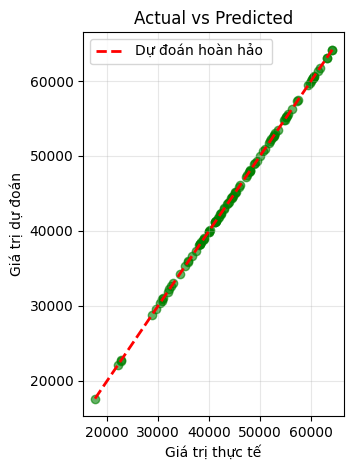

In [48]:
# Vẽ biểu đồ phân tán giữa giá trị thực tế và giá trị dự đoán
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.6, color='green')
plt.xlabel('Giá trị thực tế')
plt.ylabel('Giá trị dự đoán')
plt.title('Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label = 'Dự đoán hoàn hảo ')  
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()  

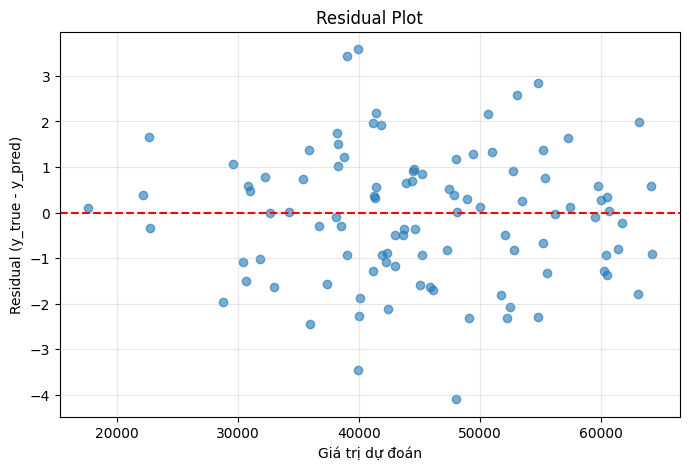

In [54]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Giá trị dự đoán')
plt.ylabel('Residual (y_true - y_pred)')
plt.title('Residual Plot')
plt.grid(alpha=0.3)
plt.show()